<a href="https://colab.research.google.com/github/harshal8704/GenAi-Practicals/blob/main/GenAi_Prac2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Aim :  Transfer Learning for Text Classification.
#Problem Statement: A news agency wants to categorize articles into sports, politics, and technolgy with limited labeled data. Fine-tune a pre-trained language model for text classification.


In [1]:
!pip install -q transformers[torch] datasets scikit-learn

In [2]:
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 1. Prepare Dataset
data = {
    'text': [
        'The football team won the championship.', 'Tennis tournament finals are today.', 'New record in athletics.', 'Basketball playoffs started.', 'Cricket world cup highlights.',
        'The government announced new policies.', 'Parliament passed the bill.', 'Election results are out.', 'The president signed the treaty.', 'Protests against the new law.',
        'AI breakthrough in computing.', 'New smartphone launched with OLED.', 'Cybersecurity threats are rising.', 'Startup unveils quantum chip.', 'Software update released.'
    ] * 4, # Creating a larger sample
    'label': [0]*20 + [1]*20 + [2]*20 # 0: Sports, 1: Politics, 2: Tech
}
df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

ds = DatasetDict({
    'train': Dataset.from_pandas(train_df),
    'validation': Dataset.from_pandas(val_df)
})

In [3]:
model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=128)

tokenized_ds = ds.map(tokenize, batched=True)
tokenized_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

Map:   0%|          | 0/48 [00:00<?, ? examples/s]

Map:   0%|          | 0/12 [00:00<?, ? examples/s]

In [4]:
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=3)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1}

# Using 'eval_strategy' which is the updated name for modern transformers
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to='none'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds['train'],
    eval_dataset=tokenized_ds['validation'],
    compute_metrics=compute_metrics,
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,1.110448,0.250000,0.257143
2,No log,1.118412,0.333333,0.335979
3,No log,1.122004,0.333333,0.335979


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=18, training_loss=1.0890443589952257, metrics={'train_runtime': 21.4986, 'train_samples_per_second': 6.698, 'train_steps_per_second': 0.837, 'total_flos': 4768911396864.0, 'train_loss': 1.0890443589952257, 'epoch': 3.0})

Training Loss,Validation Loss,Epoch,Accuracy,F1
No log,1.118412,3,0.333333,0.335979


Validation Metrics: {'eval_loss': 1.1184123754501343, 'eval_accuracy': 0.3333333333333333, 'eval_f1': 0.335978835978836}



Classification Report:
              precision    recall  f1-score   support

      Sports       0.20      0.25      0.22         4
    Politics       0.50      0.50      0.50         4
  Technology       0.33      0.25      0.29         4

    accuracy                           0.33        12
   macro avg       0.34      0.33      0.34        12
weighted avg       0.34      0.33      0.34        12



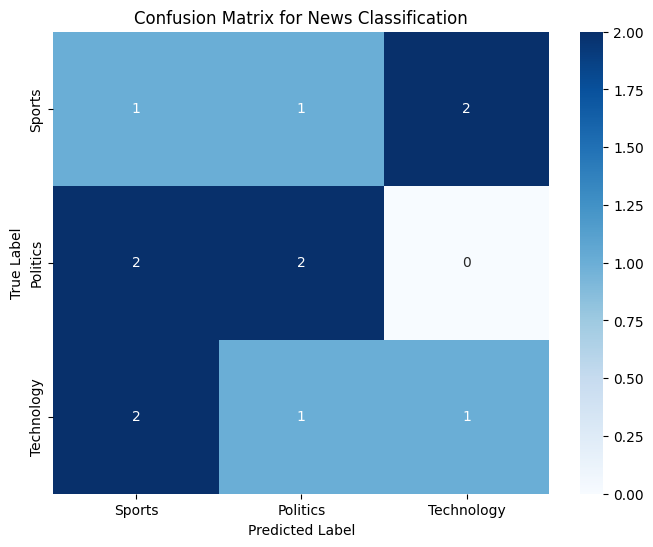

In [8]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate the model on the validation set
metrics = trainer.evaluate()
print(f"Validation Metrics: {metrics}")

# Get predictions for the validation set
predictions = trainer.predict(tokenized_ds['validation'])
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# Display Classification Report
target_names = ['Sports', 'Politics', 'Technology']
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for News Classification')
plt.show()

Training Loss,Validation Loss,Epoch,Accuracy,F1
No log,1.118412,3,0.333333,0.335979


Validation Metrics: {'eval_loss': 1.1184123754501343, 'eval_accuracy': 0.3333333333333333, 'eval_f1': 0.335978835978836}



Classification Report:
              precision    recall  f1-score   support

      Sports       0.20      0.25      0.22         4
    Politics       0.50      0.50      0.50         4
  Technology       0.33      0.25      0.29         4

    accuracy                           0.33        12
   macro avg       0.34      0.33      0.34        12
weighted avg       0.34      0.33      0.34        12



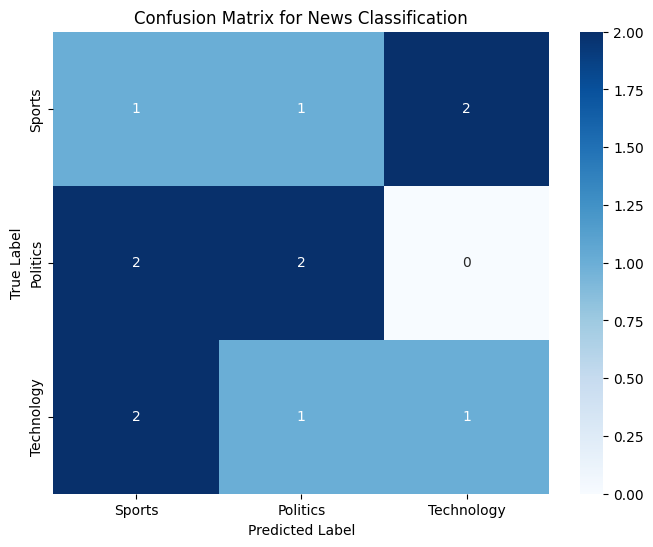

In [7]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate the model on validation set
metrics = trainer.evaluate()
print(f"Validation Metrics: {metrics}")

# Get predictions for the validation set
predictions = trainer.predict(tokenized_ds['validation'])
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# Display Classification Report
target_names = ['Sports', 'Politics', 'Technology']
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for News Classification')
plt.show()

Training Loss,Validation Loss,Epoch,Accuracy,F1
No log,1.118412,3,0.333333,0.335979


Validation Metrics: {'eval_loss': 1.1184123754501343, 'eval_accuracy': 0.3333333333333333, 'eval_f1': 0.335978835978836}



Classification Report:
              precision    recall  f1-score   support

      Sports       0.20      0.25      0.22         4
    Politics       0.50      0.50      0.50         4
  Technology       0.33      0.25      0.29         4

    accuracy                           0.33        12
   macro avg       0.34      0.33      0.34        12
weighted avg       0.34      0.33      0.34        12



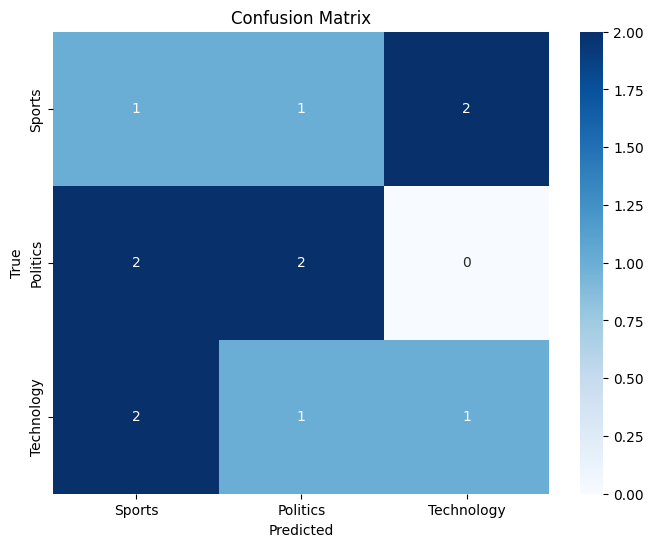

In [6]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate the model
metrics = trainer.evaluate()
print(f"Validation Metrics: {metrics}")

# Get predictions
predictions = trainer.predict(tokenized_ds['validation'])
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# Classification Report
target_names = ['Sports', 'Politics', 'Technology']
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

Training Loss,Validation Loss,Epoch,Accuracy,F1
No log,1.118412,3,0.333333,0.335979


Validation Metrics: {'eval_loss': 1.1184123754501343, 'eval_accuracy': 0.3333333333333333, 'eval_f1': 0.335978835978836}



Classification Report:
              precision    recall  f1-score   support

      Sports       0.20      0.25      0.22         4
    Politics       0.50      0.50      0.50         4
  Technology       0.33      0.25      0.29         4

    accuracy                           0.33        12
   macro avg       0.34      0.33      0.34        12
weighted avg       0.34      0.33      0.34        12



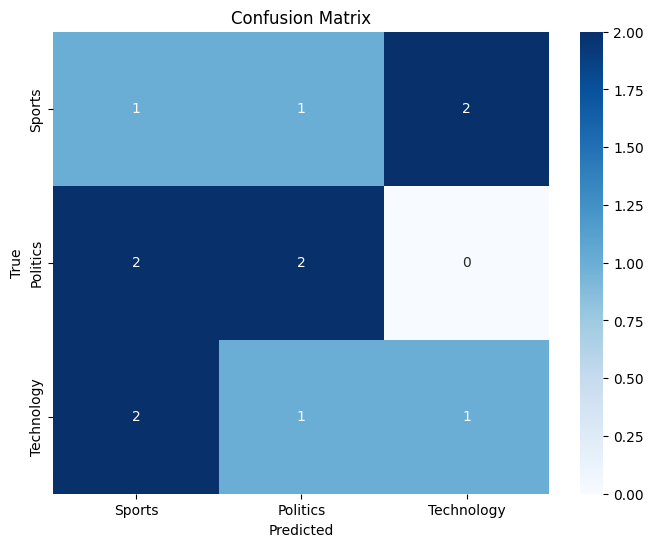

In [5]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate the model
metrics = trainer.evaluate()
print(f"Validation Metrics: {metrics}")

# Get predictions
predictions = trainer.predict(tokenized_ds['validation'])
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

# Classification Report
target_names = ['Sports', 'Politics', 'Technology']
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()